In [1]:
from spin_lattices import KagomeLattice, SquareLattice, TriangleLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import collections
collections.Sequence = collections.abc.Sequence
import pyeda.inter

2023-04-18 13:24:21.310 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-04-18 13:24:21.315 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-04-18 13:24:21.365 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
def eda_complexity(signal, number_spins):
    truthtable = "".join("1" if x > 0 else "0" if x < 0 else "-" for x in signal)
    X = pyeda.inter.ttvars('x', number_spins)
    expr, = pyeda.inter.espresso_tts(pyeda.inter.truthtable(X, truthtable))
    return expr.size

In [3]:
lattice = SquareLattice(4, 4)
rows = []
for J2 in np.linspace(0, 1, 11):
    system = HeisenbergJ1J2(lattice, 1, J2, ground_state_cache_dir=Path("groundstates"))
    system.get_eigenstates(1)
    ground_state = system.get_ground_state_in_full_basis()
    rows.append({
        "J2": J2,
        "expr_size": eda_complexity(ground_state, lattice.number_spins),
        "signal": "sign",
        "lattice": lattice.get_cache_id()
    })
    amplitude = np.where(ground_state == 0, np.nan, np.abs(ground_state))
    rows.append({
        "J2": J2,
        "expr_size": eda_complexity(amplitude - np.nanmedian(amplitude), lattice.number_spins),
        "signal": "amplitude_median_bin",
        "lattice": lattice.get_cache_id()
    })
    


2023-04-18 13:25:20.155 | DEBUG    | heisenberg_hamiltonians:__init__:427 - use_symmetries is None and lattice is in symmetries whitelist, setting use_symmetries=True, spin_inversion=1
2023-04-18 13:25:20.158 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=16
2023-04-18 13:25:20.187 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 128 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-18 13:25:20.274 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 107
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-18 13:25:20.293 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-True-1-1.pickle
2023-04-18 13:25:20.313 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -44.9139328337
2023-04-18 13:25:20.314 | DEBUG    | heisenberg_

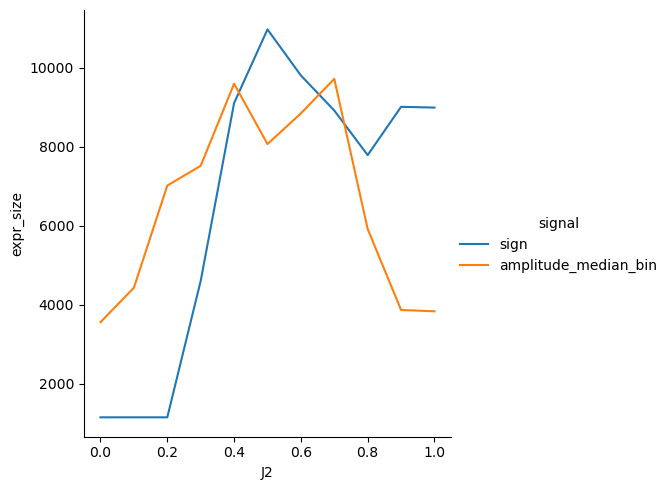

In [5]:
df = pd.DataFrame(rows)
sns.relplot(df, x="J2", y="expr_size", hue="signal", kind="line")

In [54]:
np.nansum(np.where(ground_state == 0, np.nan, np.abs(ground_state) - np.median(np.abs(ground_state))) < 0)

0

In [56]:
np.abs(ground_state) - np.median(np.abs(ground_state))

array([0., 0., 0., ..., 0., 0., 0.])

In [58]:
np.median(ground_state)

0.0